In [ ]:
print ("Hello Bioinformatics!")

Hello Bioinformatics!


In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.3 MB/s eta 0:00:00


In [ ]:
from Bio import SeqIO
print("Biopython uploaded successfully!")

Biopython uploaded successfully!


In [ ]:
fasta = """>Sequence_1
ATGCGTACGTAGCTAGCTAGCTAGCTAGCGCGCGATATAT
>Sequence_2
ATATATATGCGCGCGCGCGCGTTTTAAAAGGGCCC
>Sequence_3
GGGGCCCCAAAATTTTATATATATGCGCGCGCGC
"""

with open("sample.fasta", "w") as f:
    f.write(fasta)

print("sample.fasta created!")

sample.fasta created!


In [ ]:
from Bio import SeqIO
records = list(SeqIO.parse("human_mitochondrial.fasta", "fasta"))
print(f"Total number of sequences: {len(records)}")
for record in records:
  print(record.id, len(record.seq))

Total number of sequences: 1
NC_012920.1 16569


In [ ]:
for record in records:
  sequence = str(record.seq)
  g_count = sequence.count("G")
  c_count = sequence.count("C")
  gc_content = (g_count + c_count) / len(sequence) * 100
  print(f"{record.id}")
  print(f"Lenght: {len(sequence)}")
  print(f"GC_Content(%): %{gc_content:.2f}")
  print("-" * 30)


Sequence_1
Lenght: 40
GC_Content(%): %50.00
------------------------------
Sequence_2
Lenght: 35
GC_Content(%): %54.29
------------------------------
Sequence_3
Lenght: 34
GC_Content(%): %52.94
------------------------------


In [ ]:
!pip install pandas

In [ ]:
import pandas as pd
results = []
for record in records:
  sequence = str(record.seq)
  length = len(sequence)
  g_count = sequence.count("G")
  c_count = sequence.count("C")
  gc_content = (g_count + c_count) / length * 100
  results.append({
      "Sequence_ID": record.id,
      "Length": length,
      "GC_Content (%)": round(gc_content, 2)
  })
df = pd.DataFrame(results)
df


,Sequence_ID,Length,GC_Content (%)
0,Sequence_1,40,50.00
1,Sequence_2,35,54.29
2,Sequence_3,34,52.94


In [ ]:
!pip install matplotlib

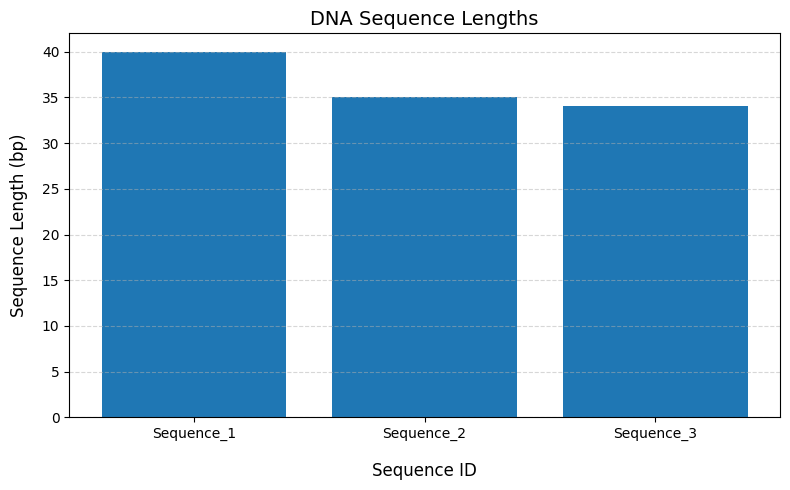

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df["Sequence_ID"], df["Length"])
plt.title("DNA Sequence Lengths", fontsize=14)
plt.xlabel("Sequence ID", fontsize=12, labelpad=15)
plt.ylabel("Sequence Length (bp)", fontsize=12, labelpad=10)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("sequence_length.png", dpi=300)

plt.show()

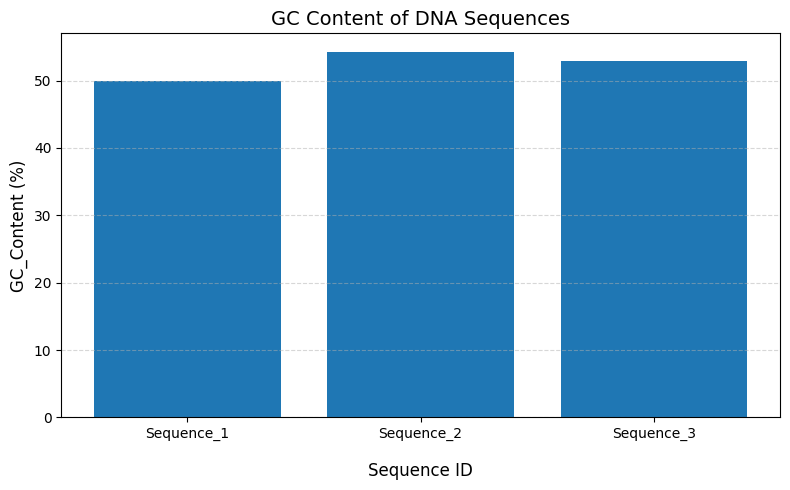

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df["Sequence_ID"], df["GC_Content (%)"])
plt.title("GC Content of DNA Sequences", fontsize=14)
plt.xlabel("Sequence ID", fontsize=12, labelpad=15)
plt.ylabel("GC_Content (%)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("gc_content.png", dpi=300)

plt.show()

In [ ]:
average_length = df["Length"].mean()
average_gc = df["GC_Content (%)"].mean()

print(f"Average Sequence Length: {average_length:.2f} bp")
print(f"Average GC Content: {average_gc:.2f}%")

Average Sequence Length: 36.33 bp
Average GC Content: 52.41%


In [ ]:
longest_sequence = df.loc[df["Length"].idxmax()]

print("Longest Sequence")
print(longest_sequence)

Longest Sequence
Sequence_ID       Sequence_1
Length                    40
GC_Content (%)          50.0
Name: 0, dtype: object


In [ ]:
highest_gc = df.loc[df["GC_Content (%)"].idxmax()]

print("Sequence with the Highest GC Content")
print(highest_gc)

Sequence with the Highest GC Content
Sequence_ID       Sequence_2
Length                    35
GC_Content (%)         54.29
Name: 1, dtype: object


In [ ]:
composition = []
for record in records:
  sequence = str(record.seq)
  composition.append({
      "Sequence_ID": record.id,
      "A": sequence.count("A"),
      "T": sequence.count("T"),
      "G": sequence.count("G"),
      "C": sequence.count("C")
  })
composition_df = pd.DataFrame(composition)
composition_df

,Sequence_ID,A,T,G,C
0,Sequence_1,10,10,11,9
1,Sequence_2,8,8,10,9
2,Sequence_3,8,8,9,9


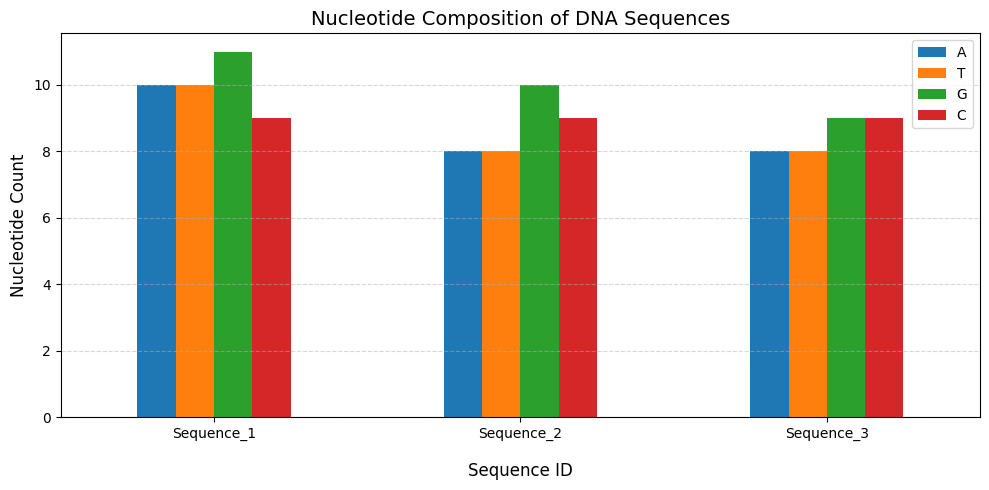

In [ ]:
composition_df.set_index("Sequence_ID").plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Nucleotide Composition of DNA Sequences", fontsize=14)
plt.xlabel("Sequence ID", labelpad=15, fontsize=12)
plt.ylabel("Nucleotide Count", fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("nucleotide_composition.png", dpi=300)
plt.show()

In [ ]:
def generate_report(df, composition_df):

  total_sequences = len(df)
  average_length = df["Length"].mean()
  average_gc = df["GC_Content (%)"].mean()

  longest_sequence = df.loc[df["Length"].idxmax(), "Sequence_ID"]
  shortest_sequence = df.loc[df["Length"].idxmin(), "Sequence_ID"]

  highest_gc = df.loc[df["GC_Content (%)"].idxmax(), "Sequence_ID"]
  lowest_gc = df.loc[df["GC_Content (%)"].idxmin(), "Sequence_ID"]

  print("=" * 50)
  print("DNA SEQUENCE ANALYSIS REPORT")
  print("=" * 50)

  print(f"Total Sequences: {total_sequences}")
  print(f"Average Sequence Length: {average_length:.2f} bp")
  print(f"Average GC Content: {average_gc:.2f}%")

  print()
  print(f"Longest Sequence: {longest_sequence}")
  print(f"Shortest Sequence: {shortest_sequence}")
  print(f"Highest GC Content: {highest_gc}")
  print(f"Lowest GC Content: {lowest_gc}")

  print()
  print("-" * 50)
  print("NUCLEOTIDE COMPOSITION")
  print("-" * 50)
  print(composition_df.to_string(index=False))

  print("=" * 50)


In [ ]:
generate_report(df, composition_df)

DNA SEQUENCE ANALYSIS REPORT
Total Sequences: 3
Average Sequence Length: 36.33 bp
Average GC Content: 52.41%

Longest Sequence: Sequence_1
Shortest Sequence: Sequence_3
Highest GC Content: Sequence_2
Lowest GC Content: Sequence_1

--------------------------------------------------
NUCLEOTIDE COMPOSITION
--------------------------------------------------
Sequence_ID  A  T  G  C
 Sequence_1 10 10 11  9
 Sequence_2  8  8 10  9
 Sequence_3  8  8  9  9


In [ ]:
composition_df.to_csv("sequence_length.csv", index=False)

In [ ]:
composition_df.to_csv("gc_content.csv", index=False)

In [ ]:
import os

os.makedirs("figures", exist_ok=True)

print("Figures folder created!")

Figures folder created!


In [ ]:
import shutil

shutil.move("sequence_length.png", "figures/sequence_length.png")
shutil.move("gc_content.png", "figures/gc_content.png")
shutil.move(
    "nucleotide_composition.png",
    "figures/nucleotide_composition.png"
)

print("Figures moved successfully!")

Figures moved successfully!


In [ ]:
df["AT_Content (%)"] = 100 - df["GC_Content (%)"]
df

,Sequence_ID,Length,GC_Content (%),AT_Content (%)
0,Sequence_1,40,50.00,50.00
1,Sequence_2,35,54.29,45.71
2,Sequence_3,34,52.94,47.06


In [ ]:
print(df[["Sequence_ID", "GC_Content (%)", "AT_Content (%)"]])

  Sequence_ID  GC_Content (%)  AT_Content (%)
0  Sequence_1           50.00           50.00
1  Sequence_2           54.29           45.71
2  Sequence_3           52.94           47.06


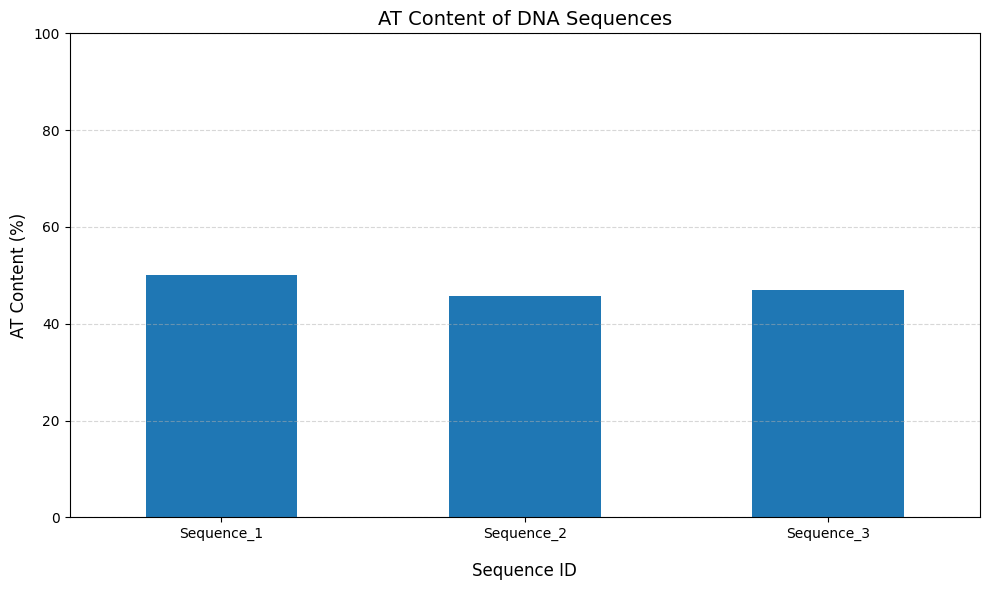

In [ ]:
import matplotlib.pyplot as plt

df.plot(
    x="Sequence_ID",
    y="AT_Content (%)",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("AT Content of DNA Sequences", fontsize=14)
plt.xlabel("Sequence ID", labelpad=15, fontsize=12)
plt.ylabel("AT Content (%)", fontsize=12)

plt.xticks(rotation=0)

plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("at_content.png", dpi=300)

plt.show()

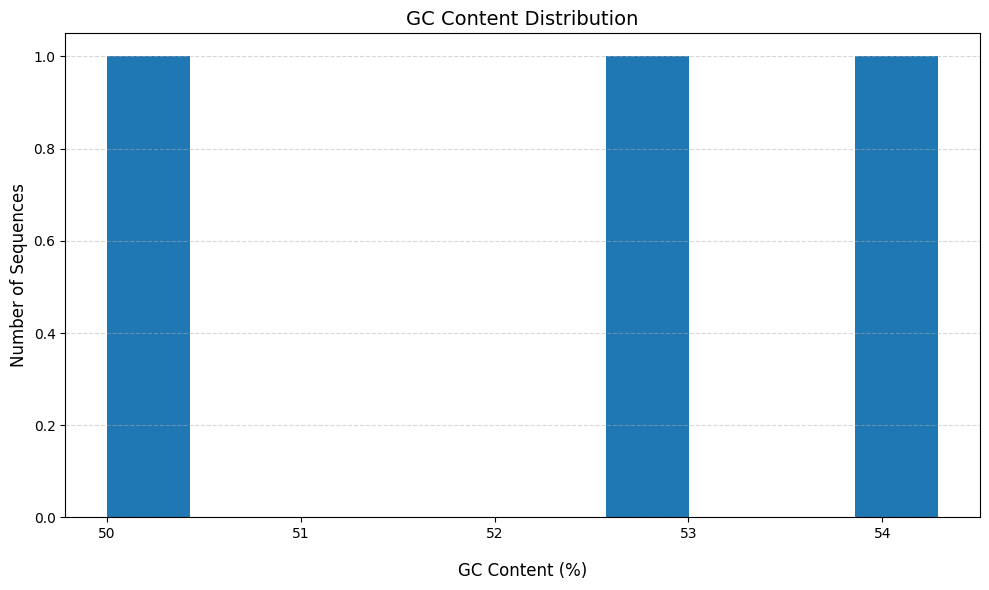

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df["GC_Content (%)"],
    bins=10
)

plt.title("GC Content Distribution", fontsize=14)
plt.xlabel("GC Content (%)", labelpad=15, fontsize=12)
plt.ylabel("Number of Sequences", fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("gc_content_distribution.png", dpi=300)

plt.show()

In [ ]:
df.to_csv("at_content.csv", index=False)


In [ ]:
import os

os.makedirs("figures", exist_ok=True)

In [ ]:
import shutil

shutil.move("at_content.png", "figures/at_content.png")
shutil.move(
    "gc_content_distribution.png",
    "figures/gc_content_distribution.png"
)

print("New figures moved successfully!")

New figures moved successfully!


In [ ]:
import requests

In [ ]:
url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_012920.1&rettype=fasta&retmode=text"

response = requests.get(url)

print(response.status_code)

200


In [ ]:
with open("human_mitochondrial.fasta", "w") as f:
    f.write(response.text)

print("FASTA file saved!")

FASTA file saved!


In [ ]:
url = "https://ftp.ncbi.nlm.nih.gov/toolbox/gbench/samples/16SRNA_Deino_87seq.aln"

response = requests.get(url)

print(response.status_code)

200


In [ ]:
with open("16SRNA_Deino_87seq.aln", "w") as f:
    f.write(response.text)

print("Dataset saved!")

Dataset saved!


In [ ]:
print(response.text[:1500])

>ref|NR_117835.1
--------------------------AGAGTTTGATCCTGGCTCAGGGTGAACGCTGGCG
GCGTGC----TTAAGACATGCAAGTCGAACGG-CCT------TCTTCG-G-AAGGC-AGT
GGCGCACGGGTGAGTAACGCGTAACTGACCTA-CCCTCAAGT-CTGGAATAACGGGTCGA
AA--GATCCGCTAATACTGGATGTGCAGTGTCGC-TGTGGCGACACTGTAAAGATTGA-T
---CGCTTGAGGATGGGGTTGCGTT-TCATCAGCTGGTTGGTGGGGTAAAGG-CCTACCA
AGGCGACGACGAATAGCCGGCCTGAGAGGGTGGCCGG-CCACAGGGGCACTGAGACACGG
GTCCCACTCCTACGGGAGGCAGCAGTTAGGAATCTTCCA-CAAT---GGGCGCAAGCCTG
ATGGAGCGA-CGCCGCGT-GAGGGATGAAGGTTTTC-GGATCGTAAACCTCTGAATCTGG
GACGAAA-GACGCGTC-AAGC-GGGATGACGGTACC-AGAGTAATAGCACCGGCTAACTC
CGTG-CCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTACCCGGAATCACTGGGCGTA
AAGGGCGTGTAGGCGGGACCGTAAGTCTGGTTTTAAAGACTGAGGCTCAACCTCAGGAG-
TGGACTGGATACTGCGATCCTTGACCTCTGGG-GAGGCAACCGG-AATTCCTGGTGTAGC
GGTGGAATGCGTAGATA-CCAGGAGGAACACCAATGG-CGAAGGCAGGTTGCTGGACAGA
AGGTGACGCTGAGGCGCGAAAGTGT-GGGGAGCAAA-CCGGATTAGATACCCGGGTAGTC
CACACCCTAAACGATGTACGTTGGCTCATGGCAGGATGCTGTCATGGGCGAAGCTAACGC
GATAAACGTACCGCCTGGGAAGTACGGCCGCAAGGTTGAAACTCAAAGGAATTGACGGGG
GCCCGCA

In [ ]:
from Bio import SeqIO

records = list(SeqIO.parse("16SRNA_Deino_87seq.aln", "fasta"))

print("Total number of sequences:", len(records))

Total number of sequences: 87


In [ ]:
for record in records:
    record.seq = record.seq.__class__(
        str(record.seq).replace("-", "")
    )

print("Gaps removed.")

Gaps removed.


In [ ]:
for record in records[:5]:
    print(record.id, len(record.seq))

ref|NR_117835.1 1469
ref|NR_044497.1 1470
gb|KU042972.2 1468
ref|NR_108580.1 1469
gb|JQ396615.1 1495


In [ ]:
sequence_ids = []
lengths = []

for record in records:
    sequence_ids.append(record.id)
    lengths.append(len(record.seq))

print("Number of sequemces:", len(sequence_ids))
print("First 5 IDs:", sequence_ids[:5])
print("First 5 lengths:", lengths[:5])


Number of sequemces: 87
First 5 IDs: ['ref|NR_117835.1', 'ref|NR_044497.1', 'gb|KU042972.2', 'ref|NR_108580.1', 'gb|JQ396615.1']
First 5 lengths: [1469, 1470, 1468, 1469, 1495]


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Sequence_ID": sequence_ids,
    "Length": lengths
})
df.head()

,Sequence_ID,Length
0,ref|NR_117835.1,1469
1,ref|NR_044497.1,1470
2,gb|KU042972.2,1468
3,ref|NR_108580.1,1469
4,gb|JQ396615.1,1495


In [ ]:
for record in records:
    sequence = str(record.seq)
    g_count = sequence.count("G")
    c_count = sequence.count("C")
    gc_content = (g_count + c_count) / len(sequence) * 100
    print(f"{record.id}")
    print(f"Length: {len(sequence)}")
    print(f"GC_Content(%): %{gc_content:.2f}")
    print("-" * 30)

In [ ]:
gc_contents = []

for record in records:
    sequence = str(record.seq)
    g_count = sequence.count("G")
    c_count = sequence.count("C")
    gc_content = (g_count + c_count) / len(sequence) * 100
    gc_contents.append(gc_content)

df["GC_Content (%)"] = gc_contents
df.head()

,Sequence_ID,Length,GC_Content (%),AT_Content (%)
0,ref|NR_117835.1,1469,55.820286,44.18
1,ref|NR_044497.1,1470,56.394558,43.61
2,gb|KU042972.2,1468,56.607629,43.39
3,ref|NR_108580.1,1469,56.637168,43.36
4,gb|JQ396615.1,1495,56.454849,43.55


In [ ]:
df["AT_Content (%)"] = 100 - df["GC_Content (%)"]
df.head()

,Sequence_ID,Length,GC_Content (%),AT_Content (%)
0,ref|NR_117835.1,1469,55.820286,44.179714
1,ref|NR_044497.1,1470,56.394558,43.605442
2,gb|KU042972.2,1468,56.607629,43.392371
3,ref|NR_108580.1,1469,56.637168,43.362832
4,gb|JQ396615.1,1495,56.454849,43.545151


In [ ]:
df["GC_Content (%)"] = df["GC_Content (%)"].round(2)
df["AT_Content (%)"] = df["AT_Content (%)"].round(2)

df.head()

,Sequence_ID,Length,GC_Content (%),AT_Content (%)
0,ref|NR_117835.1,1469,55.82,44.18
1,ref|NR_044497.1,1470,56.39,43.61
2,gb|KU042972.2,1468,56.61,43.39
3,ref|NR_108580.1,1469,56.64,43.36
4,gb|JQ396615.1,1495,56.45,43.55


In [ ]:
nucleotide_data = []

for record in records:
    sequence = str(record.seq)

    nucleotide_data.append({
        "Sequence_ID": record.id,
        "A": sequence.count("A"),
        "T": sequence.count("T"),
        "G": sequence.count("G"),
        "C": sequence.count("C")
    })

nucleotide_df = pd.DataFrame(nucleotide_data)

nucleotide_df.head()

,Sequence_ID,A,T,G,C
0,ref|NR_117835.1,362,287,474,346
1,ref|NR_044497.1,357,284,486,343
2,gb|KU042972.2,355,282,486,345
3,ref|NR_108580.1,358,279,476,356
4,gb|JQ396615.1,365,286,485,359


In [ ]:
df.to_csv("sequence_analysis_results.csv", index=False)
nucleotide_df.to_csv("nucleotide_composition.csv", index=False)

print("CSV files updated successfully!")

CSV files updated successfully!


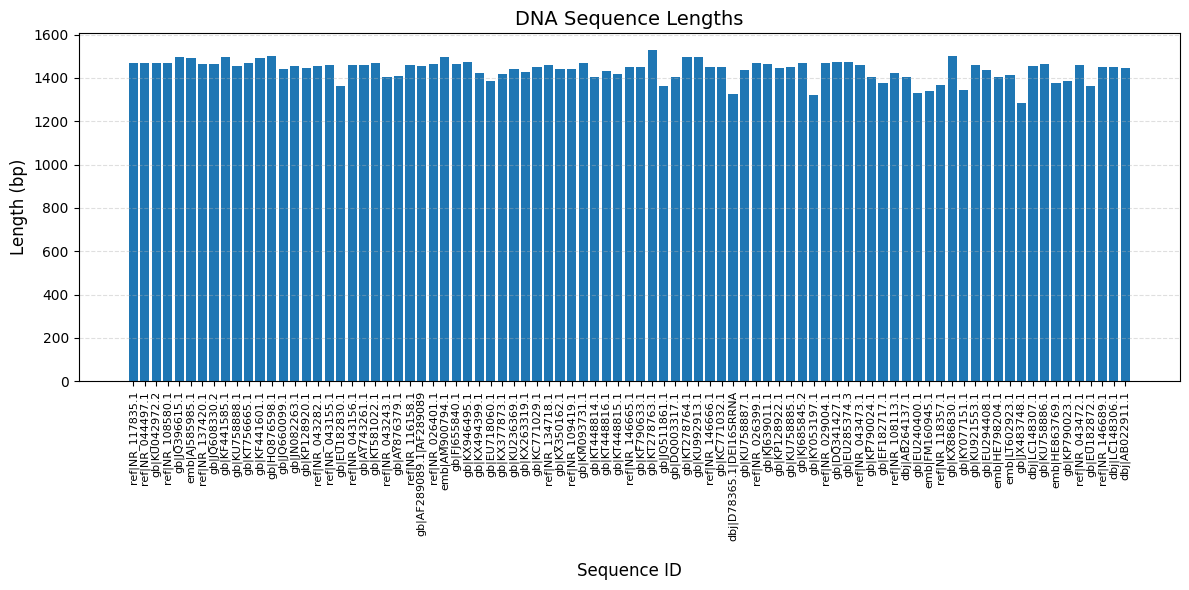

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(df["Sequence_ID"], df["Length"])

plt.title("DNA Sequence Lengths", fontsize=14)
plt.xlabel("Sequence ID", labelpad=15, fontsize=12)
plt.ylabel("Length (bp)", fontsize=12)

plt.xticks(rotation=90, fontsize=8)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("sequence_length.png", dpi=300)
plt.show()


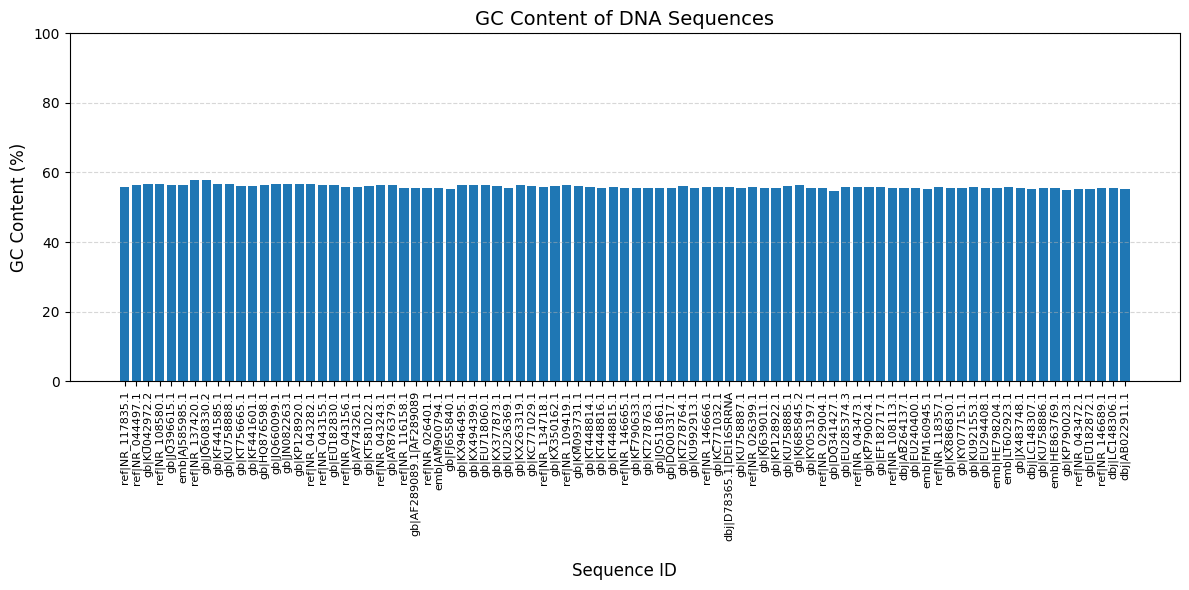

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(df["Sequence_ID"], df["GC_Content (%)"])

plt.title("GC Content of DNA Sequences", fontsize=14)
plt.xlabel("Sequence ID", labelpad=15, fontsize=12)
plt.ylabel("GC Content (%)", fontsize=12)

plt.xticks(rotation=90, fontsize=8)
plt.ylim(0, 100)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("gc_content.png", dpi=300)
plt.show()

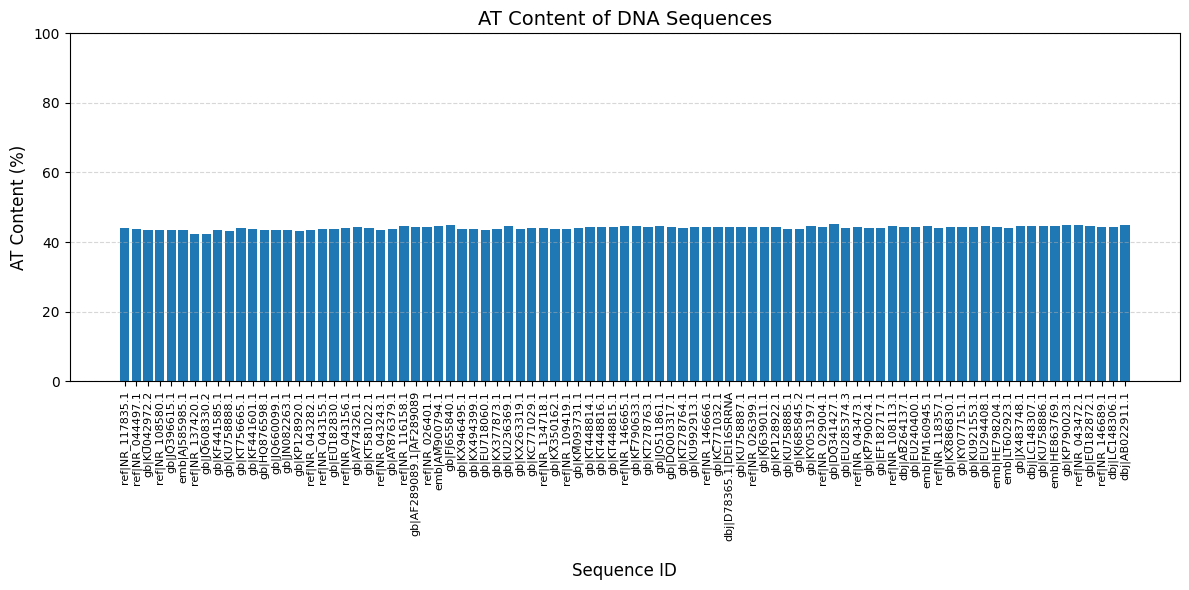

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(df["Sequence_ID"], df["AT_Content (%)"])

plt.title("AT Content of DNA Sequences", fontsize=14)
plt.xlabel("Sequence ID", labelpad=15, fontsize=12)
plt.ylabel("AT Content (%)", fontsize=12)

plt.xticks(rotation=90, fontsize=8)
plt.ylim(0, 100)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("at_content.png", dpi=300)

plt.show()

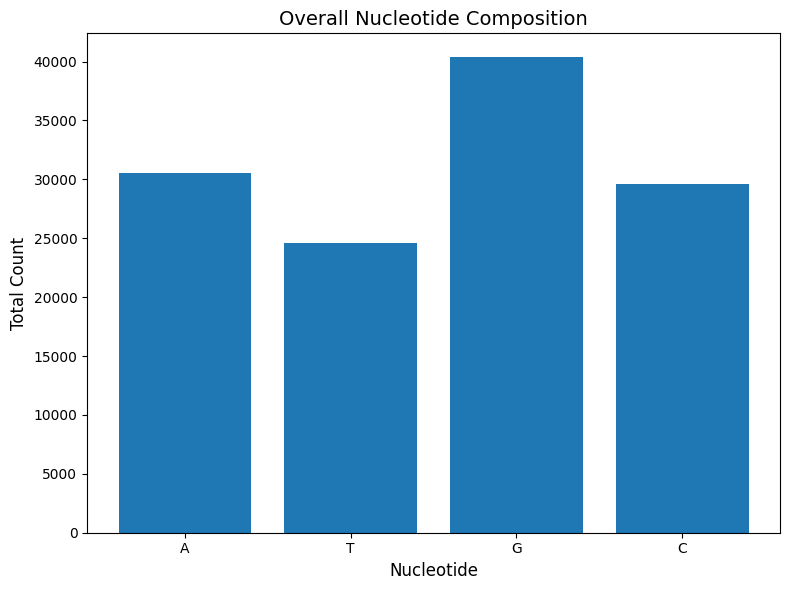

In [ ]:
total_counts = nucleotide_df[["A", "T", "G", "C"]].sum()

plt.figure(figsize=(8, 6))

plt.bar(total_counts.index, total_counts.values)

plt.title("Overall Nucleotide Composition", fontsize=14)
plt.xlabel("Nucleotide", fontsize=12)
plt.ylabel("Total Count", fontsize=12)

plt.tight_layout()

plt.savefig("nucleotide_composition.png", dpi=300)

plt.show()

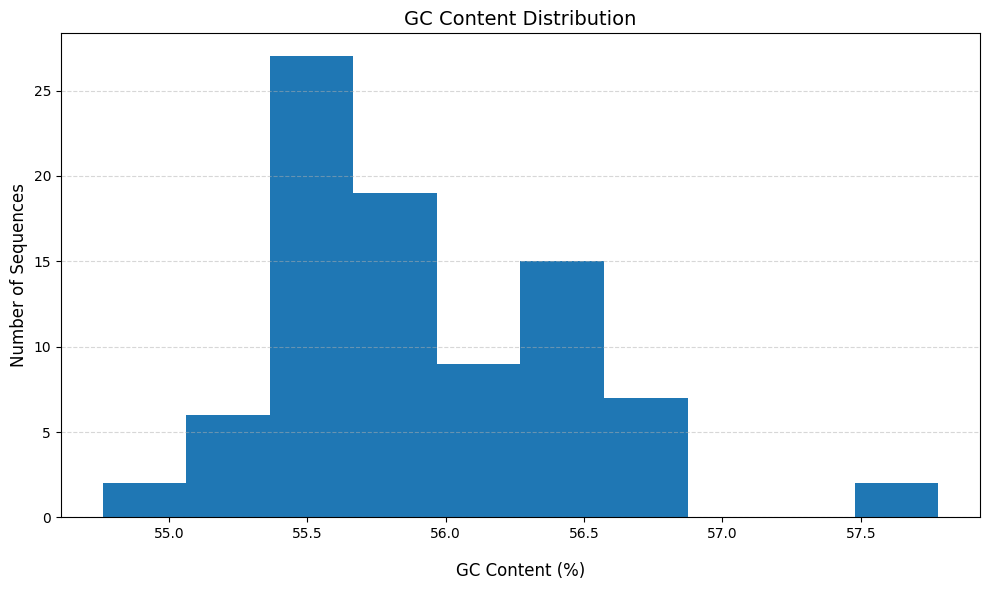

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["GC_Content (%)"],
    bins=10
)

plt.title("GC Content Distribution", fontsize=14)
plt.xlabel("GC Content (%)", fontsize=12, labelpad=15)
plt.ylabel("Number of Sequences", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("gc_content_distribution.png", dpi=300)

plt.show()

In [ ]:
print("Average GC Content:", round(df["GC_Content (%)"].mean(), 2))
print("Minimum GC Content:", round(df["GC_Content (%)"].min(), 2))
print("Maximum GC Content:", round(df["GC_Content (%)"].max(), 2))

Average GC Content: 55.91
Minimum GC Content: 54.76
Maximum GC Content: 57.78


In [ ]:
min_index = df["GC_Content (%)"].idxmin()
max_index = df["GC_Content (%)"].idxmax()

print("Lowest GC:")
print(df.loc[min_index])

print("\nHighest GC:")
print(df.loc[max_index])

Lowest GC:
Sequence_ID       gb|DQ341427.1
Length                     1472
GC_Content (%)            54.76
AT_Content (%)            45.24
Name: 61, dtype: object

Highest GC:
Sequence_ID       ref|NR_137420.1
Length                       1466
GC_Content (%)              57.78
AT_Content (%)              42.22
Name: 6, dtype: object


In [ ]:
gc_stats = df["GC_Content (%)"].describe()

print(gc_stats)

count    87.000000
mean     55.909310
std       0.528211
min      54.760000
25%      55.540000
50%      55.760000
75%      56.295000
max      57.780000
Name: GC_Content (%), dtype: float64


In [ ]:
print("GC Content Statistics")
print("----------------------")
print("Mean:", round(df["GC_Content (%)"].mean(), 2))
print("Median:", round(df["GC_Content (%)"].median(), 2))
print("Standard Deviation:", round(df["GC_Content (%)"].std(), 2))
print("Minimum:", round(df["GC_Content (%)"].min(), 2))
print("Maximum:", round(df["GC_Content (%)"].max(), 2))
print("Range:", round(
    df["GC_Content (%)"].max() - df["GC_Content (%)"].min(), 2
))

GC Content Statistics
----------------------
Mean: 55.91
Median: 55.76
Standard Deviation: 0.53
Minimum: 54.76
Maximum: 57.78
Range: 3.02


In [ ]:
print("Sequence Length Statistics")
print("--------------------------")
print("Mean:", round(df["Length"].mean(), 2))
print("Median:", round(df["Length"].median(), 2))
print("Standard Deviation:", round(df["Length"].std(), 2))
print("Minimum:", df["Length"].min())
print("Maximum:", df["Length"].max())
print("Range:", df["Length"].max() - df["Length"].min())

Sequence Length Statistics
--------------------------
Mean: 1437.95
Median: 1451.0
Standard Deviation: 46.61
Minimum: 1285
Maximum: 1529
Range: 244


In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Sequences",
        "Mean Length",
        "Median Length",
        "Mean GC Content (%)",
        "Median GC Content (%)",
        "GC Standard Deviation (%)",
        "Minimum GC Content (%)",
        "Maximum GC Content (%)"
    ],
    "Value": [
        len(df),
        round(df["Length"].mean(), 2),
        round(df["Length"].median(), 2),
        round(df["GC_Content (%)"].mean(), 2),
        round(df["GC_Content (%)"].median(), 2),
        round(df["GC_Content (%)"].std(), 2),
        round(df["GC_Content (%)"].min(), 2),
        round(df["GC_Content (%)"].max(), 2)
    ]
})

summary

,Metric,Value
0,Number of Sequences,87.00
1,Mean Length,1437.95
2,Median Length,1451.00
3,Mean GC Content (%),55.91
4,Median GC Content (%),55.76
5,GC Standard Deviation (%),0.53
6,Minimum GC Content (%),54.76
7,Maximum GC Content (%),57.78


In [ ]:
summary.to_csv("analysis_summary.csv", index=False)

print("Analysis summary saved!")

Analysis summary saved!


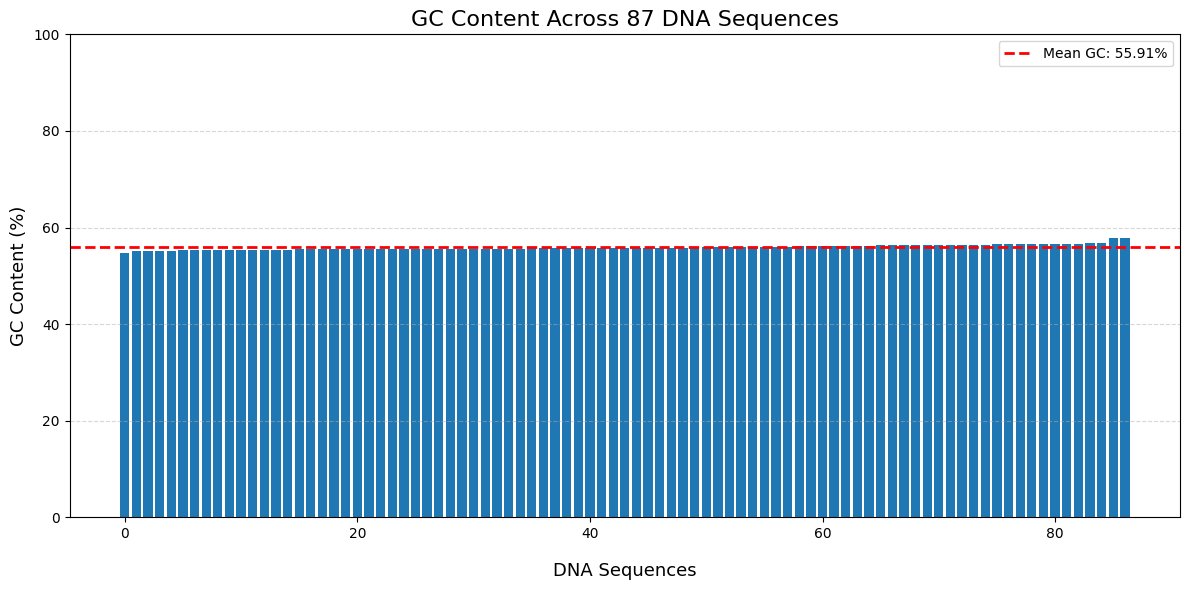

In [ ]:
import matplotlib.pyplot as plt

gc_sorted = df.sort_values("GC_Content (%)")

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(gc_sorted)),
    gc_sorted["GC_Content (%)"]
)

plt.axhline(
    df["GC_Content (%)"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean GC: {df['GC_Content (%)'].mean():.2f}%"
)

plt.title("GC Content Across 87 DNA Sequences", fontsize=16)
plt.xlabel("DNA Sequences", fontsize=13, labelpad=15)
plt.ylabel("GC Content (%)", fontsize=13)

plt.ylim(0, 100)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("gc_content_improved.png", dpi=300)

plt.show()

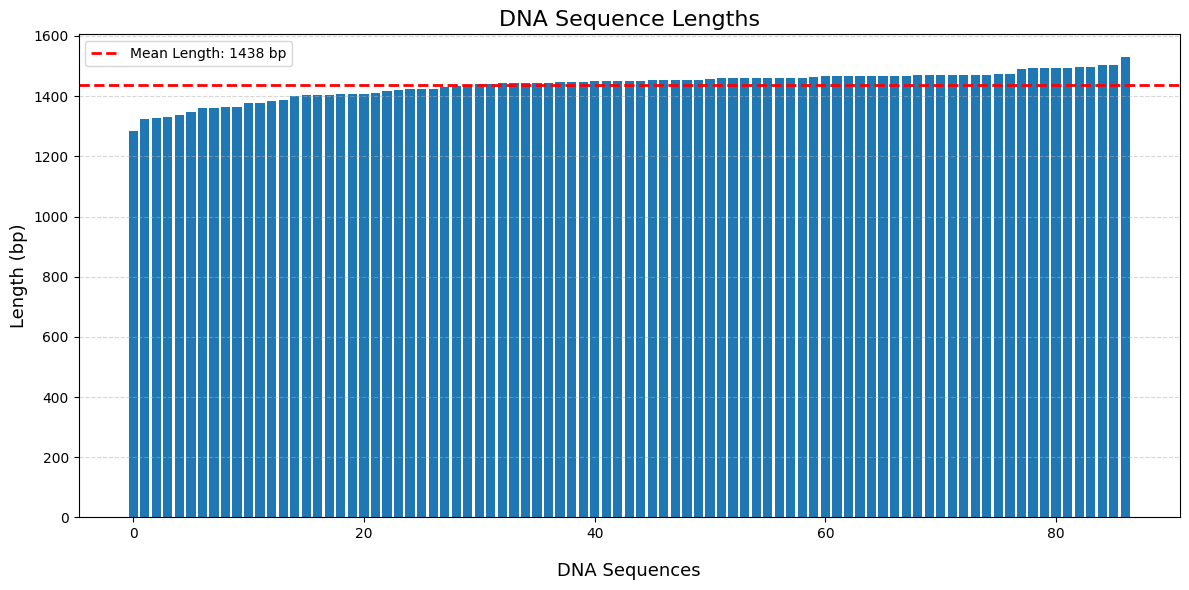

In [ ]:
length_sorted = df.sort_values("Length")

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(length_sorted)),
    length_sorted["Length"]
)

plt.axhline(
    df["Length"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean Length: {df['Length'].mean():.0f} bp"
)

plt.title("DNA Sequence Lengths", fontsize=16)
plt.xlabel("DNA Sequences", fontsize=13, labelpad=15)
plt.ylabel("Length (bp)", fontsize=13)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("sequence_length_improved.png", dpi=300)

plt.show()

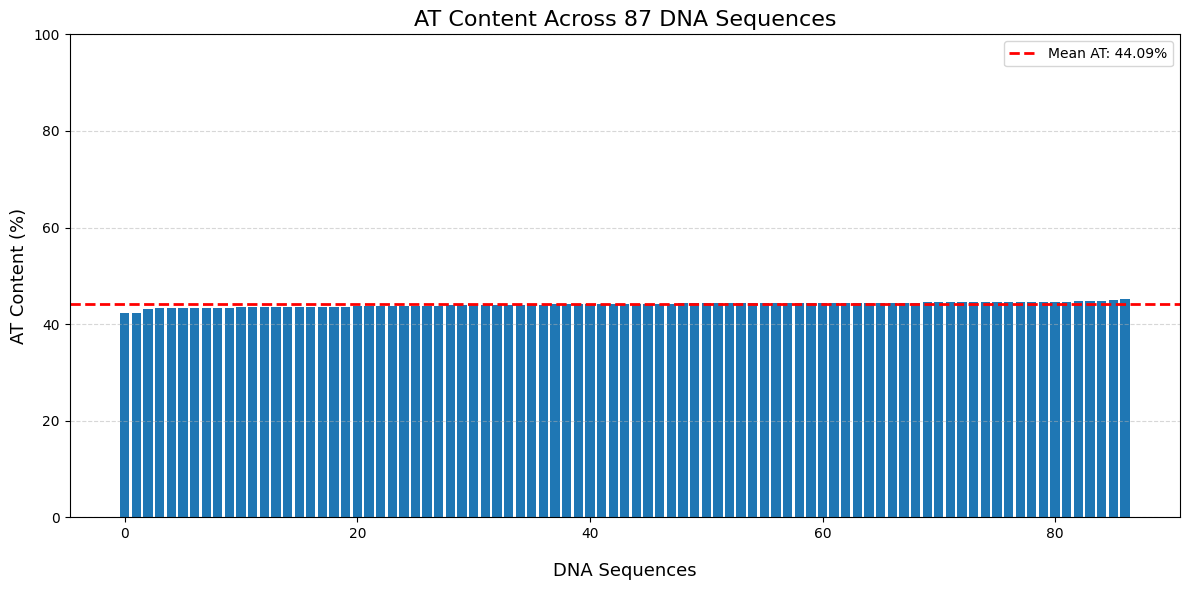

In [ ]:
at_sorted = df.sort_values("AT_Content (%)")

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(at_sorted)),
    at_sorted["AT_Content (%)"]
)

plt.axhline(
    df["AT_Content (%)"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean AT: {df['AT_Content (%)'].mean():.2f}%"
)

plt.title("AT Content Across 87 DNA Sequences", fontsize=16)
plt.xlabel("DNA Sequences", fontsize=13, labelpad=15)
plt.ylabel("AT Content (%)", fontsize=13)

plt.ylim(0, 100)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("at_content_improved.png", dpi=300)

plt.show()

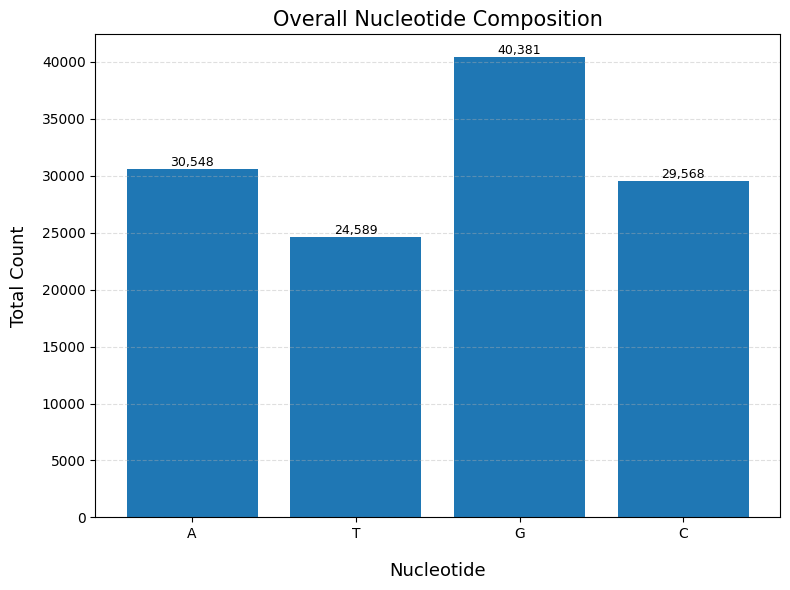

In [ ]:
total_counts = nucleotide_df[["A", "T", "G", "C"]].sum()

plt.figure(figsize=(8, 6))

bars = plt.bar(
    total_counts.index,
    total_counts.values
)

plt.title("Overall Nucleotide Composition", fontsize=15)
plt.xlabel("Nucleotide", fontsize=13, labelpad=15)
plt.ylabel("Total Count", fontsize=13, labelpad=10)

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add values above bars

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig("nucleotide_composition_improved.png", dpi=300)

plt.show()

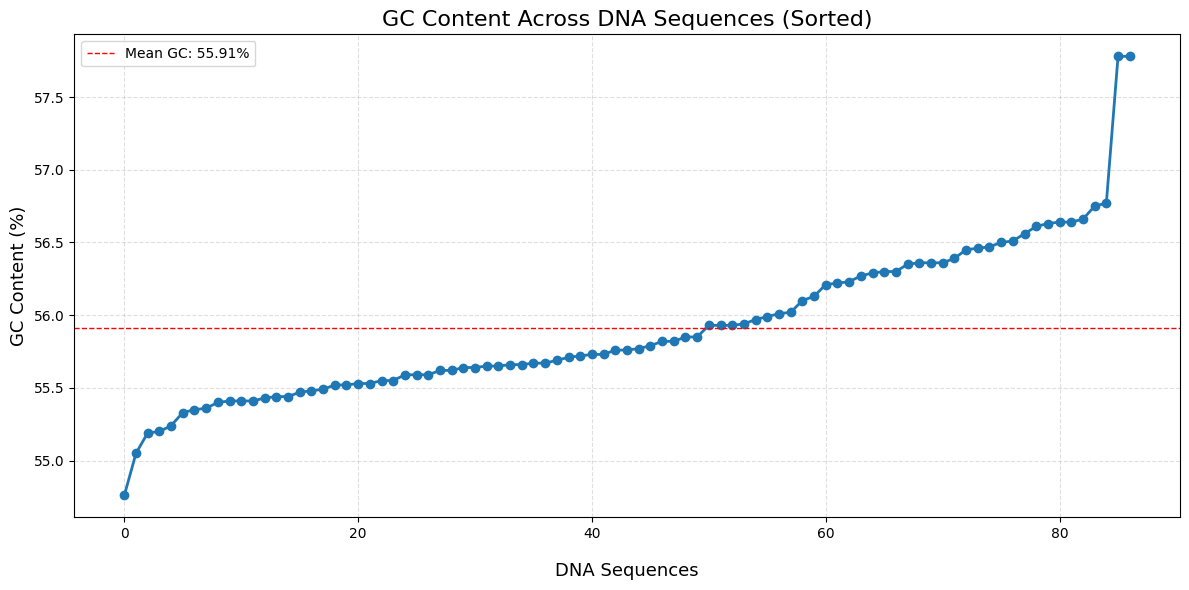

In [ ]:
gc_sorted = df.sort_values("GC_Content (%)")

plt.figure(figsize=(12, 6))

plt.plot(
    range(len(gc_sorted)),
    gc_sorted["GC_Content (%)"],
    marker="o",
    linewidth=2
)

plt.axhline(
    df["GC_Content (%)"].mean(),
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Mean GC: {df['GC_Content (%)'].mean():.2f}%"
)

plt.title("GC Content Across DNA Sequences (Sorted)", fontsize=16)
plt.xlabel("DNA Sequences", fontsize=13, labelpad=15)
plt.ylabel("GC Content (%)", fontsize=13)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig("gc_content_distribution_improved.png", dpi=300)

plt.show()

In [ ]:
import os

import shutil

if os.path.exists("figures"):

    shutil.rmtree("figures")

os.makedirs("figures")

print("Figures folder recreated!")

Figures folder recreated!


In [127]:
print(os.listdir("figures"))

['gc_content_distribution.png', 'gc_content.png', 'at_content.png', 'nucleotide_composition.png', 'sequence_length.png']
